
# LoRA Fine-Tuning using Banking77 Dataset

---

# Objective

In this notebook, we will:

- Understand the Banking77 dataset
- Learn why PEFT (Parameter-Efficient Fine-Tuning) is useful
- Apply LoRA to DistilBERT
- Fine-tune using a banking-domain dataset
- Evaluate model performance
- Perform inference on real banking queries

---

# Why Banking77?

Large Language Models are trained on general internet text.

However, enterprise applications require:

- domain-specific vocabulary
- business terminology
- customer-support understanding
- enterprise customization

Banking77 is a real-world banking customer support dataset containing:

- transaction issues
- card payment problems
- transfer failures
- ATM complaints
- account-related queries

This makes it an excellent dataset for demonstrating:

## Domain Adaptation using LoRA



# Install Required Libraries

We remove incompatible torchao versions to avoid PEFT errors in Google Colab.


In [ ]:

# !pip uninstall -y torchao -q

# # !pip install -q transformers==4.51.3 peft==0.15.2 accelerate==1.6.0 datasets evaluate scikit-learn
# !pip install transformers datasets peft accelerate evaluate scikit-learn -q


# Restart Runtime (Important)

After installation:

Runtime → Restart Session

Then run the notebook from the beginning.



# Import Required Libraries


In [ ]:

import torch
import numpy as np
import pandas as pd


from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

from sklearn.metrics import accuracy_score, f1_score



# Load Banking77 Dataset


In [ ]:

dataset = load_dataset("mteb/banking77")

dataset


README.md:   0%|          | 0.00/16.6k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  294kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 91.4kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9993 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3076 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 9993
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 3076
    })
})


# Dataset Overview

The dataset contains:

- customer banking queries
- intent labels
- 77 banking categories

Examples:

- cash withdrawal issue
- card payment failed
- beneficiary problem
- transfer pending
- balance inquiry



# View Sample Data


In [ ]:

dataset["train"][0]


{'text': 'I am still waiting on my card?',
 'label': 11,
 'label_text': 'card_arrival'}


# Label Names


In [ ]:
# Create a mapping:
# numeric label -> readable label name
label_mapping = {}

for row in dataset["train"]:
    label_mapping[row["label"]] = row["label_text"]


# Create label_names in the CORRECT numeric order:
# label_names[0] = name of class 0
# label_names[1] = name of class 1
# ...
label_names = [
    label_mapping[i]
    for i in sorted(label_mapping.keys())
]


print("Number of Classes:", len(label_names))

label_names[:10]


Number of Classes: 77


['activate_my_card',
 'age_limit',
 'apple_pay_or_google_pay',
 'atm_support',
 'automatic_top_up',
 'balance_not_updated_after_bank_transfer',
 'balance_not_updated_after_cheque_or_cash_deposit',
 'beneficiary_not_allowed',
 'cancel_transfer',
 'card_about_to_expire']

In [ ]:
print("Training Samples:", len(dataset["train"]))
print("Test Samples:", len(dataset["test"]))

total_samples = len(dataset["train"]) + len(dataset["test"])

print("Total Samples:", total_samples)
print("Number of Classes:", len(label_names))

Training Samples: 9993
Test Samples: 3076
Total Samples: 13069
Number of Classes: 77


In [ ]:
from collections import Counter

train_labels = dataset["train"]["label"]

class_counts = Counter(train_labels)

# for label_id, count in class_counts.items():
#     print(f"{label_names[label_id]} : {count}")

In [ ]:

class_distribution = pd.DataFrame({
    "Class": [label_names[k] for k in class_counts.keys()],
    "Samples": list(class_counts.values())
})

class_distribution = class_distribution.sort_values(
    by="Samples",
    ascending=False
)

class_distribution.head(10)

,Class,Samples
20,card_payment_fee_charged,187
37,direct_debit_payment_not_recognised,182
26,balance_not_updated_after_cheque_or_cash_deposit,181
19,wrong_amount_of_cash_received,180
72,cash_withdrawal_charge,177
49,transaction_charged_twice,175
39,declined_cash_withdrawal,173
55,transfer_fee_charged,172
67,balance_not_updated_after_bank_transfer,171
21,transfer_not_received_by_recipient,171


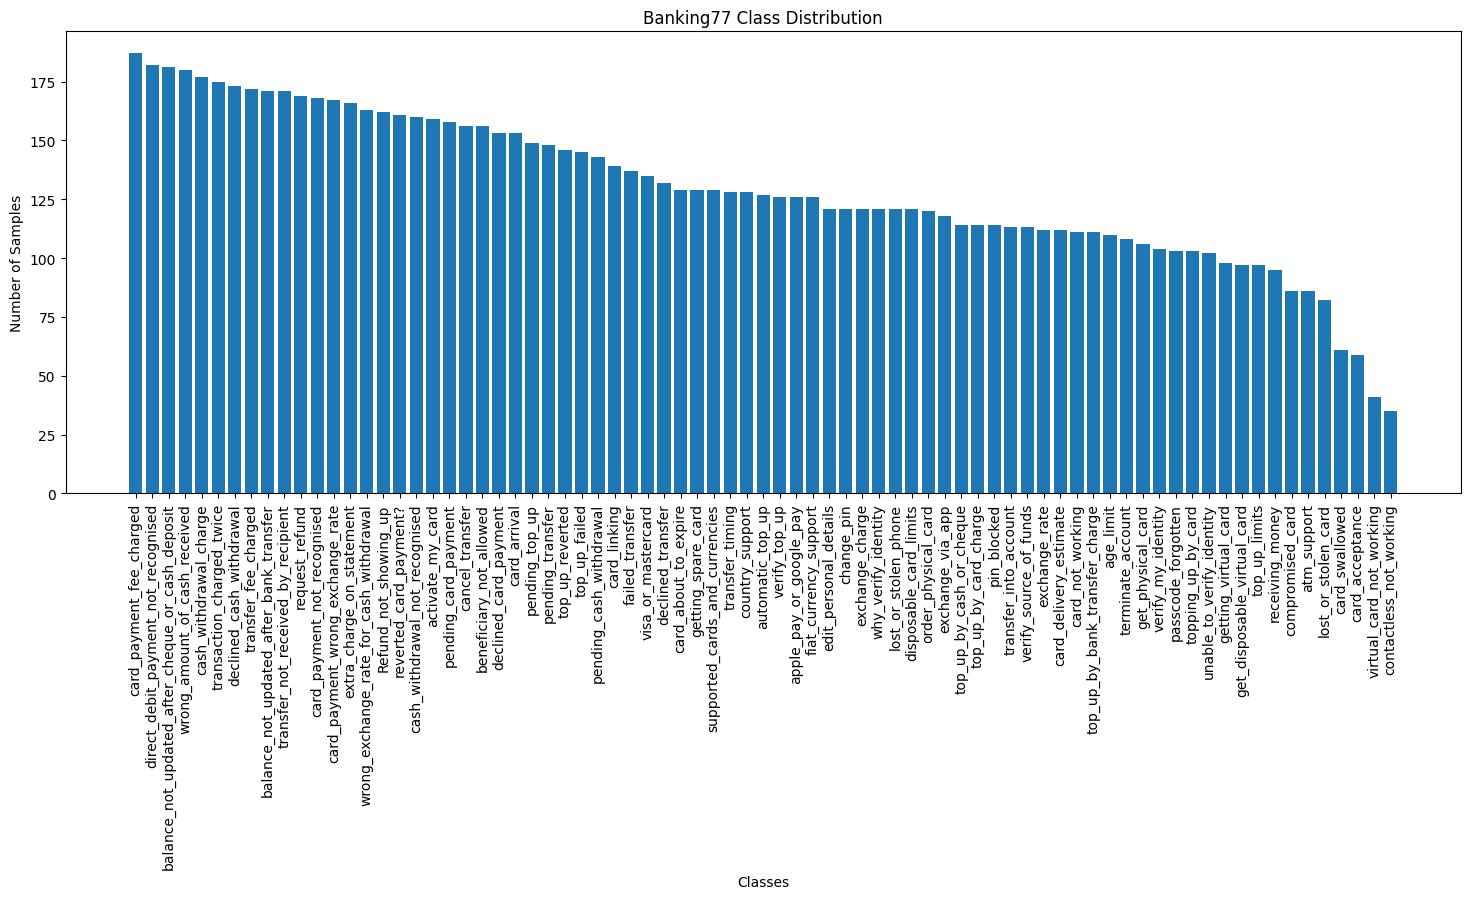

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.bar(
    class_distribution["Class"],
    class_distribution["Samples"]
)

plt.xticks(rotation=90)

plt.title("Banking77 Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Number of Samples")

plt.show()


# Load Tokenizer

We use DistilBERT tokenizer.


In [ ]:

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)



# Tokenization

Transformers cannot process raw text directly.

The tokenizer converts text into:

- input_ids
- attention_mask


In [ ]:

def tokenize_function(example):

    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/9993 [00:00<?, ? examples/s]

Map:   0%|          | 0/3076 [00:00<?, ? examples/s]


# Prepare Dataset for PyTorch


In [ ]:

tokenized_dataset = tokenized_dataset.remove_columns(["text"])

tokenized_dataset.set_format("torch")



# Load Pretrained DistilBERT Model

We use a pretrained transformer model trained on massive general English data.


In [ ]:

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=77
)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



# What is LoRA?

LoRA adds a small trainable low-rank adaptation branch parallel to frozen pretrained layers.

Instead of training all parameters:

- pretrained weights remain frozen
- only tiny low-rank matrices are trained

This drastically reduces:

- GPU memory
- computation cost
- training time



# Configure LoRA


In [ ]:

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin", "k_lin", "v_lin"]
)



# Apply LoRA to DistilBERT


In [ ]:

!pip install -q --upgrade torchao==0.16.0

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.4 MB/s eta 0:00:00


trainable params: 1,092,173 || all params: 68,104,858 || trainable%: 1.6037



# Data Collator

Handles dynamic padding during batching.


In [ ]:

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)



# Define Evaluation Metrics


In [ ]:

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1
    }



# Training Configuration


In [ ]:

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none"
)



# Create Trainer


In [ ]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)



# Train LoRA Model


In [ ]:

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.558871,1.292143,0.694733,0.662776
2,0.853130,0.733245,0.814694,0.810616


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.558871,1.292143,0.694733,0.662776
2,0.853130,0.733245,0.814694,0.810616
3,0.629744,0.597642,0.844928,0.843830
4,0.529945,0.556054,0.854356,0.854172


TrainOutput(global_step=2500, training_loss=1.2381982818603516, metrics={'train_runtime': 180.5387, 'train_samples_per_second': 221.404, 'train_steps_per_second': 13.847, 'total_flos': 1359045318998016.0, 'train_loss': 1.2381982818603516, 'epoch': 4.0})


# Evaluate Model


In [ ]:

results = trainer.evaluate()

results


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.529945,0.556054,4,0.854356,0.854172


{'eval_loss': 0.5560536980628967,
 'eval_accuracy': 0.8543563068920677,
 'eval_f1': 0.8541719463045153}

In [ ]:
train_predictions = trainer.predict(tokenized_dataset["train"])


train_preds = np.argmax(train_predictions.predictions, axis=-1)

train_f1 = f1_score(
    train_predictions.label_ids,
    train_preds,
    average="weighted"
)

print("Train Weighted F1:", train_f1)

Train Weighted F1: 0.8812829081896375


In [ ]:
test_predictions = trainer.predict(tokenized_dataset["test"])
test_preds = np.argmax(test_predictions.predictions, axis=-1)

test_f1 = f1_score(
    test_predictions.label_ids,
    test_preds,
    average="weighted"
)

print("Test Weighted F1:", test_f1)

Test Weighted F1: 0.8541719463045153



# Inference

Now we test the fine-tuned banking assistant.


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=16, bias=False)
                  )
     

In [ ]:

id2label = {i: label for i, label in enumerate(label_names)}


In [ ]:

def predict_intent(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    print("Customer Query:", text)
    print("Predicted Intent:", id2label[prediction])



# Test Inference


In [ ]:

predict_intent("My card payment failed")

predict_intent("Cash withdrawal is not working")

predict_intent("I did not receive my bank transfer")

predict_intent("My beneficiary is not getting added")


Customer Query: My card payment failed
Predicted Intent: declined_card_payment
Customer Query: Cash withdrawal is not working
Predicted Intent: pending_cash_withdrawal
Customer Query: I did not receive my bank transfer
Predicted Intent: balance_not_updated_after_bank_transfer
Customer Query: My beneficiary is not getting added
Predicted Intent: beneficiary_not_allowed



# Key Takeaways

## Students Learned

- Enterprise domain adaptation
- Transformer fine-tuning
- LoRA architecture
- PEFT concepts
- Evaluation metrics
- Real-world inference

---

## Most Important Insight

LoRA trains only a tiny subset of parameters while keeping pretrained transformer knowledge frozen.


Without PEFT. Just use distilBert

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=77
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:

training_args = TrainingArguments(
    output_dir="./results1",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none"
)


In [ ]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.604653,0.517877,0.847529,0.833562
2,0.311601,0.344000,0.906697,0.906912
3,0.138185,0.301452,0.924252,0.924019
4,0.026406,0.292094,0.930104,0.929944


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.5563930557250977, metrics={'train_runtime': 209.3593, 'train_samples_per_second': 190.925, 'train_steps_per_second': 11.941, 'total_flos': 1325517250526208.0, 'train_loss': 0.5563930557250977, 'epoch': 4.0})

In [ ]:

results = trainer.evaluate()

results

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.026406,0.292094,4,0.930104,0.929944


{'eval_loss': 0.29209429025650024,
 'eval_accuracy': 0.9301040312093628,
 'eval_f1': 0.9299436457955261}

In [ ]:
train_predictions = trainer.predict(tokenized_dataset["train"])


train_preds = np.argmax(train_predictions.predictions, axis=-1)

train_f1 = f1_score(
    train_predictions.label_ids,
    train_preds,
    average="weighted"
)

print("Train Weighted F1:", train_f1)

Train Weighted F1: 0.9950929175700329


In [ ]:
test_predictions = trainer.predict(tokenized_dataset["test"])
test_preds = np.argmax(test_predictions.predictions, axis=-1)

test_f1 = f1_score(
    test_predictions.label_ids,
    test_preds,
    average="weighted"
)

print("Test Weighted F1:", test_f1)

Test Weighted F1: 0.9299436457955261
